<a href="https://colab.research.google.com/github/Naveen-gale/DATA-SCENS-LEARNING/blob/main/emotionanalyses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from datasets import load_dataset

In [43]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [44]:
label_name = emotion_dataset['train'].features['label'].names
label_name

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [45]:
df_train = pd.DataFrame(
    {
        "text": train_text,
        "label": [label_name[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        "text": test_text,
        "label": [label_name[i] for i in test_label]
    }
)

In [46]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [47]:
df_train.isna().sum()

,0
text,0
label,0


In [48]:
df_train.duplicated().sum()

np.int64(1)

In [49]:
df_train.describe()

,text,label
count,16000,16000
unique,15969,6
top,im still not sure why reilly feels the need to...,joy
freq,2,5362


In [50]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


In [51]:
df_train.label.value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


In [52]:
df_train.drop_duplicates(inplace=True)

In [53]:
df_train.duplicated().sum()


np.int64(0)

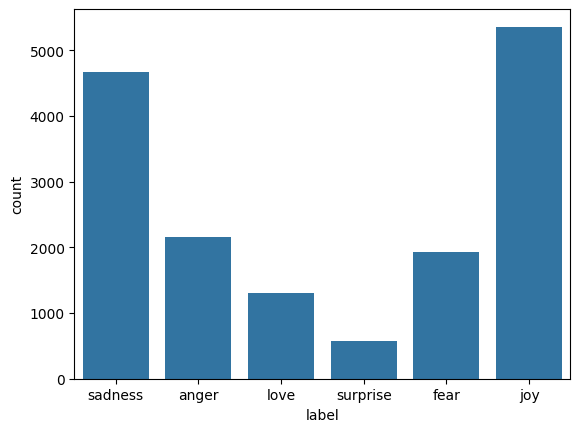

In [54]:
sns.countplot(x='label', order= df_train['label'],  data=df_train)
plt.show()

In [55]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000
max_len = 100


In [56]:
tokenize = Tokenizer(max_words, oov_token='x')
tokenize.fit_on_texts(df_train['text'])
sequences_train = tokenize.texts_to_sequences(df_train['text'])
sequences_test = tokenize.texts_to_sequences(df_test['text'])
sequences_padd_train = pad_sequences(sequences_train, maxlen=max_len)
sequences_padd_test = pad_sequences(sequences_test, maxlen=max_len)


In [57]:
train_label= np.array(train_label)
test_label = np.array(test_label)

In [58]:
train_label

array([0, 0, 3, ..., 1, 3, 0])

In [59]:
num_classes = len(np.unique(train_label))
num_classes


print(f"Vocabulary Size: {len(tokenize.word_index)}")
print(f"Max Sentence Length: {sequences_padd_train.shape[1]}")

Vocabulary Size: 15212
Max Sentence Length: 100


In [60]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
                                        class_weight = "balanced",
                                        classes = np.unique(train_label),
                                        y = train_label
                                    )

class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [61]:

from tensorflow.keras.callbacks import EarlyStopping

eraly_stop= EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [63]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU
rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(units=64, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(units=32),
    Dense(num_classes, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [65]:
# Align train_label to match the cleaned df_train
label_mapping = {name: idx for idx, name in enumerate(label_name)}
train_label_cleaned = np.array(df_train['label'].map(label_mapping))

rnn_model.fit(
    sequences_padd_train,
    train_label_cleaned,
    validation_data=(sequences_padd_test, test_label),
    epochs=20,
    batch_size=32,
    callbacks=[eraly_stop],
    class_weight=class_weight_dict,
)

rnn_loss, rnn_acc = rnn_model.evaluate(sequences_padd_test, test_label)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_acc}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.1471 - loss: 1.8343 - val_accuracy: 0.1120 - val_loss: 1.8266
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.1531 - loss: 1.7984 - val_accuracy: 0.1375 - val_loss: 1.7879
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.1631 - loss: 1.7952 - val_accuracy: 0.0800 - val_loss: 1.8298
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.1814 - loss: 1.7702 - val_accuracy: 0.3350 - val_loss: 1.7343
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.3143 - loss: 1.5805 - val_accuracy: 0.3230 - val_loss: 1.6982
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.3917 - loss: 1.4837 - val_accuracy: 0.3180 - val_loss: 1.7185
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.4912 - loss: 1.3084 - val_accuracy: 0.4725 - val_loss: 1.4070
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.6515 - loss: 0.9130 - 

In [68]:
LSTM_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(units=128, return_sequences=True),
    Dropout(0.2),
    LSTM(units=64, return_sequences=True),
    Dropout(0.2),
    LSTM(units=32),
    Dense(num_classes, activation='softmax')
])

LSTM_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

LSTM_model.fit(
    sequences_padd_train,
    train_label_cleaned,
    validation_data=(sequences_padd_test, test_label),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[eraly_stop]
)

lstm_loss, lstm_acc = LSTM_model.evaluate(sequences_padd_test, test_label)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_acc}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.5097 - loss: 1.2060 - val_accuracy: 0.8735 - val_loss: 0.4738
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9077 - loss: 0.2868 - val_accuracy: 0.8920 - val_loss: 0.3079
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9362 - loss: 0.1676 - val_accuracy: 0.9145 - val_loss: 0.2448
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9531 - loss: 0.1142 - val_accuracy: 0.9080 - val_loss: 0.2731
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9607 - loss: 0.0950 - val_accuracy: 0.9050 - val_loss: 0.2317
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9664 - loss: 0.0827 - val_accuracy: 0.9105 - val_loss: 0.2511
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9721 - loss: 0.0664 - val_accuracy: 0.9180 - val_loss: 0.2653
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9796 - loss: 0.0517 - val_ac

In [69]:
GRU_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    GRU(units=128, return_sequences=True),
    Dropout(0.2),
    GRU(units=64, return_sequences=True),
    Dropout(0.2),
    GRU(units=32),
    Dense(num_classes, activation='softmax')
])

GRU_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

GRU_model.fit(
    sequences_padd_train,
    train_label_cleaned,
    validation_data=(sequences_padd_test, test_label),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[eraly_stop]
)

gru_loss, gru_acc = GRU_model.evaluate(sequences_padd_test, test_label)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_acc}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.5868 - loss: 1.0948 - val_accuracy: 0.8710 - val_loss: 0.4326
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9112 - loss: 0.2461 - val_accuracy: 0.9025 - val_loss: 0.2726
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9447 - loss: 0.1374 - val_accuracy: 0.9230 - val_loss: 0.2254
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9516 - loss: 0.1219 - val_accuracy: 0.9070 - val_loss: 0.2713
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9596 - loss: 0.0931 - val_accuracy: 0.9175 - val_loss: 0.2430
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9650 - loss: 0.0830 - val_accuracy: 0.9105 - val_loss: 0.2846
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9745 - loss: 0.0648 - val_accuracy: 0.9165 - val_loss: 0.2310
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9772 - loss: 0.0528 - va

In [72]:
best_model

,model,loss,accuracy
0,RNN,0.907162,0.716
1,LSTM,0.231658,0.905
2,GRU,0.225375,0.923


In [74]:
from tensorflow.keras.layers import Bidirectional

biGRU= Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(GRU(units=128, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(GRU(units=64, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(GRU(units=32)),
    Dense(num_classes, activation='softmax')
])


biGRU.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

biGRU.fit(
    sequences_padd_train,
    train_label_cleaned,
    validation_data=(sequences_padd_test, test_label),
    epochs=20,
    batch_size=3,
    callbacks=[eraly_stop],
    class_weight=class_weight_dict
)

biGRU_loss, biGRU_acc = biGRU.evaluate(sequences_padd_test, test_label)
print(f"BiGRU Loss: {biGRU_loss}")
print(f"BiGRU Accuracy: {biGRU_acc}")

Epoch 1/20
5333/5333 ━━━━━━━━━━━━━━━━━━━━ 179s 33ms/step - accuracy: 0.1430 - loss: 1.8200 - val_accuracy: 0.1375 - val_loss: 1.8228
Epoch 2/20
5333/5333 ━━━━━━━━━━━━━━━━━━━━ 161s 30ms/step - accuracy: 0.1723 - loss: 1.7945 - val_accuracy: 0.3620 - val_loss: 1.4364
Epoch 3/20
5333/5333 ━━━━━━━━━━━━━━━━━━━━ 155s 29ms/step - accuracy: 0.7113 - loss: 0.7574 - val_accuracy: 0.8970 - val_loss: 0.3274
Epoch 4/20
5333/5333 ━━━━━━━━━━━━━━━━━━━━ 161s 30ms/step - accuracy: 0.9314 - loss: 0.1897 - val_accuracy: 0.9235 - val_loss: 0.1925
Epoch 5/20
5333/5333 ━━━━━━━━━━━━━━━━━━━━ 159s 30ms/step - accuracy: 0.9431 - loss: 0.1405 - val_accuracy: 0.9260 - val_loss: 0.1967
Epoch 6/20
5333/5333 ━━━━━━━━━━━━━━━━━━━━ 199s 29ms/step - accuracy: 0.9542 - loss: 0.1142 - val_accuracy: 0.9240 - val_loss: 0.2106
Epoch 7/20
5333/5333 ━━━━━━━━━━━━━━━━━━━━ 156s 29ms/step - accuracy: 0.9677 - loss: 0.0821 - val_accuracy: 0.9225 - val_loss: 0.2095
Epoch 8/20
5333/5333 ━━━━━━━━━━━━━━━━━━━━ 158s 30ms/step - accuracy: 

In [76]:
best_model= pd.DataFrame({
    "model": ["RNN", "LSTM", "GRU", "biGRU"],
    "loss": [rnn_loss, lstm_loss, gru_loss, biGRU_loss],
    "accuracy": [rnn_acc, lstm_acc, gru_acc, biGRU_acc]
}

).sort_values(by="accuracy", ascending=False)

In [77]:
best_model

,model,loss,accuracy
3,biGRU,0.192535,0.9235
2,GRU,0.225375,0.9230
1,LSTM,0.231658,0.9050
0,RNN,0.907162,0.7160


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       581
           1       0.98      0.90      0.94       695
           2       0.75      0.99      0.86       159
           3       0.89      0.95      0.92       275
           4       0.89      0.85      0.87       224
           5       0.65      0.97      0.78        66

    accuracy                           0.92      2000
   macro avg       0.86      0.93      0.89      2000
weighted avg       0.94      0.92      0.93      2000



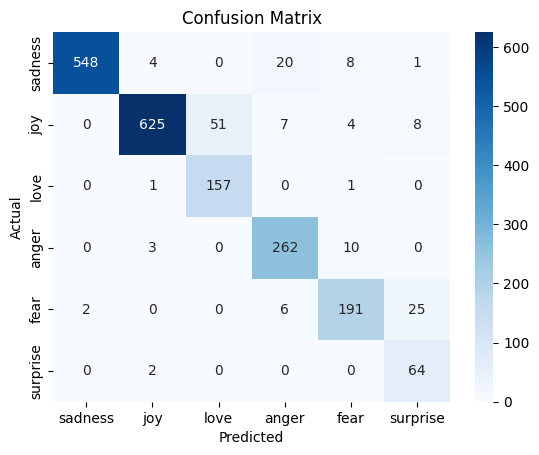

In [81]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

bigru_pred = np.argmax(biGRU.predict(sequences_padd_test ), axis=1)
print(classification_report(test_label, bigru_pred))
sns.heatmap(confusion_matrix(test_label, bigru_pred), annot=True, fmt='d' , cmap='Blues', xticklabels=label_name, yticklabels=label_name)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [82]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

In [83]:
smaple_sequences = tokenize.texts_to_sequences(sample_texts)
smaple_sequences_padd = pad_sequences(smaple_sequences, maxlen=max_len)
smaple_pred = np.argmax(biGRU.predict(smaple_sequences_padd), axis=1)
for i in range(len(sample_texts)):
    print(f"Text: {sample_texts[i]}")
    print(f"predection emotion ", {label_name[smaple_pred[i]]})

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Text: I can't believe how happy I am right now, this is amazing!
predection emotion  {'surprise'}
Text: I feel so alone and hopeless today.
predection emotion  {'sadness'}
Text: I am furious that they cancelled the trip at the last minute.
predection emotion  {'anger'}
Text: I feel terrified when walking down dark alleyways alone.
predection emotion  {'fear'}
Text: I was shocked and completely surprised by the unexpected gift!
predection emotion  {'surprise'}


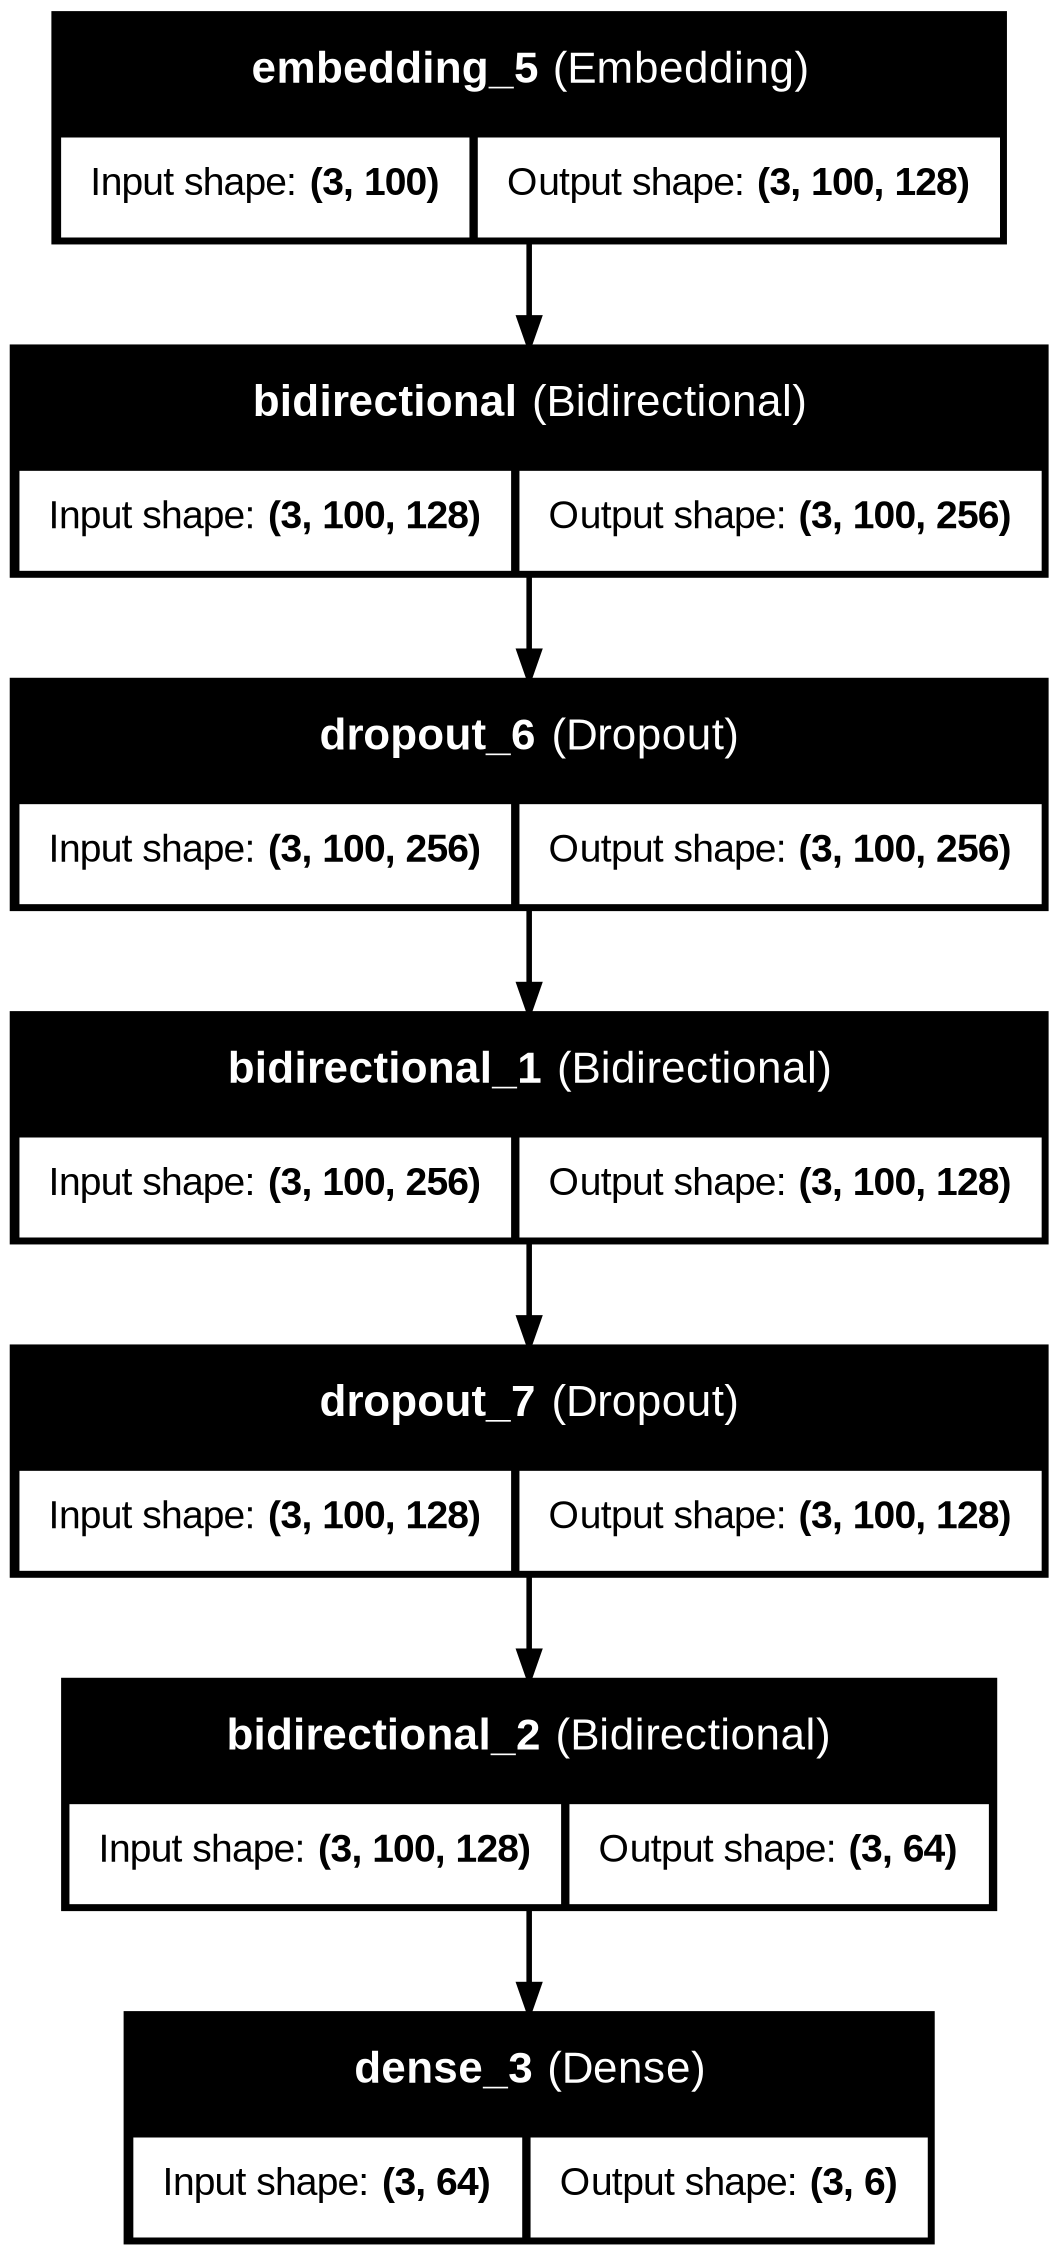

In [85]:
from tensorflow.keras.utils import plot_model

plot_model(
    biGRU,
    to_file='bigru_model.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True
)

In [88]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
biGRU.save(os.path.join(model_dir, 'biGRU.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'biGRU.pkl'), 'wb') as file:
  pickle.dump(tokenize, file)